# 1 Importar librerias

In [ ]:
import os
import requests
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from pickle import dump
from sklearn.tree import plot_tree
import pickle

# 2 Importar datos procesados del anterior proyecto

In [6]:
# Carga de datos 
path_train = "../data/processed/clean_train.csv"
path_test = "../data/processed/clean_test.csv"
train_data = pd.read_csv(path_train)
test_data = pd.read_csv(path_test)

# Separar características (X) y variable objetivo (y)
X_train = train_data.drop(["Outcome"], axis = 1)
y_train = train_data["Outcome"]

X_test = test_data.drop(["Outcome"], axis = 1)
y_test = test_data["Outcome"]

# Verificación rápida de la carga
print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

Datos de entrenamiento: (586, 8)
Datos de prueba: (147, 8)


# 3 Construcción y Optimización del Random Forest

## 3.1 Definimos los rangos para los dos hiperparámetros principales

In [ ]:
n_estimators_list = [10, 50, 60, 100, 150, 200]
max_depth_list = [5, 10, None] # None significa que el árbol crece hasta que las hojas sean puras

# Lista para almacenar los resultados y poder graficar
results = []

print("Entrenando y comparando modelos...")

Entrenando y comparando modelos...


## 3.2 Bucle para probar diferentes combinaciones

In [ ]:
for depth in max_depth_list:
    accuracies = []
    for n in n_estimators_list:
        # Creamos y entrenamos el modelo
        model = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        
        # Predicción y cálculo de precisión
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Configuración: n_estimators={n}, max_depth={depth} -> Accuracy: {acc:.4f}")
    
    # Guardamos los resultados de esta profundidad para la gráfica
    results.append((depth, accuracies))

Configuración: n_estimators=10, max_depth=5 -> Accuracy: 0.7347
Configuración: n_estimators=50, max_depth=5 -> Accuracy: 0.7347
Configuración: n_estimators=60, max_depth=5 -> Accuracy: 0.7347
Configuración: n_estimators=100, max_depth=5 -> Accuracy: 0.7211
Configuración: n_estimators=150, max_depth=5 -> Accuracy: 0.7279
Configuración: n_estimators=200, max_depth=5 -> Accuracy: 0.7347
Configuración: n_estimators=10, max_depth=10 -> Accuracy: 0.6735
Configuración: n_estimators=50, max_depth=10 -> Accuracy: 0.7143
Configuración: n_estimators=60, max_depth=10 -> Accuracy: 0.7211
Configuración: n_estimators=100, max_depth=10 -> Accuracy: 0.7211
Configuración: n_estimators=150, max_depth=10 -> Accuracy: 0.7143
Configuración: n_estimators=200, max_depth=10 -> Accuracy: 0.7347
Configuración: n_estimators=10, max_depth=None -> Accuracy: 0.6939
Configuración: n_estimators=50, max_depth=None -> Accuracy: 0.6939
Configuración: n_estimators=60, max_depth=None -> Accuracy: 0.6939
Configuración: n_es

## 3.3 Graficar las conclusiones

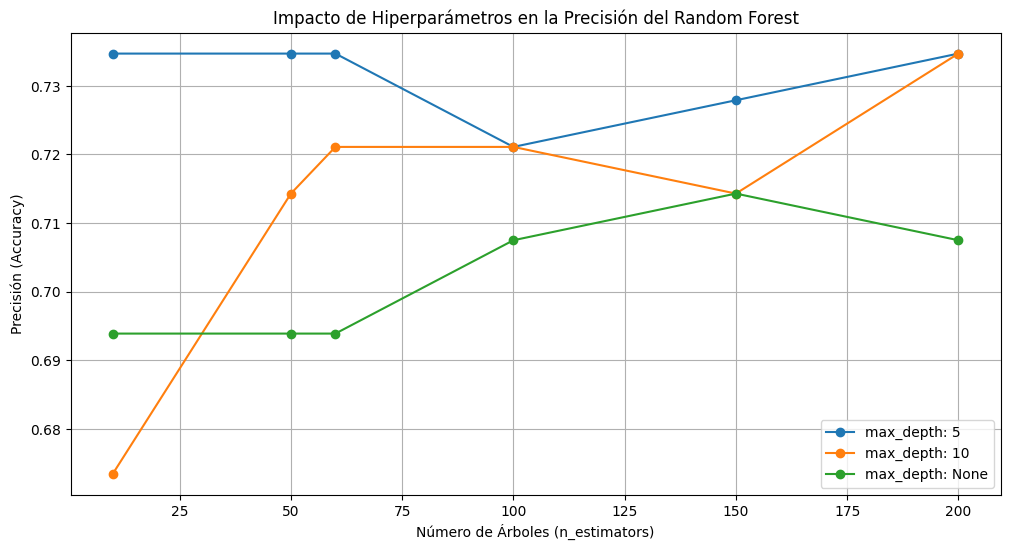

In [9]:
plt.figure(figsize=(12, 6))

for depth, accs in results:
    label_name = f'max_depth: {depth}' if depth is not None else 'max_depth: None'
    plt.plot(n_estimators_list, accs, marker='o', label=label_name)

plt.title('Impacto de Hiperparámetros en la Precisión del Random Forest')
plt.xlabel('Número de Árboles (n_estimators)')
plt.ylabel('Precisión (Accuracy)')
plt.legend()
plt.grid(True)
plt.show()

# 4 Elección de modelo y almacenamiento

In [11]:
# Elegimos max_depth=5 y n_estimators=60 porque alcanzó el máximo de precisión rápidamente
model_final = RandomForestClassifier(n_estimators=60, max_depth=5, random_state=42)
model_final.fit(X_train, y_train)

,n_estimators,60
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Guardar el modelo en la ruta del proyecto
ruta_final = "/workspaces/steven10015-intro-ml/models/random_forest_final.sav"

# Aseguramos que el modelo final esté listo 
# n_estimators=60 y max_depth=5 dieron el primer pico alto de estabilidad
model_final = RandomForestClassifier(n_estimators=60, max_depth=5, random_state=42)
model_final.fit(X_train, y_train)

# Guardado usando la ruta directa
with open(ruta_final, 'wb') as f:
    pickle.dump(model_final, f)

print(f"¡Conseguido! El modelo se guardó en: {ruta_final}")

¡Conseguido! El modelo se guardó en: /workspaces/steven10015-intro-ml/models/random_forest_final.sav
